C:\Users\veron\AppData\Local\Temp\ipykernel_23112\2488748299.py:52: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,12

Total samples: 136556


C:\Users\veron\AppData\Local\Temp\ipykernel_23112\2488748299.py:110: DtypeWarning: Columns (106,107,228,230,243,245,247,249,251,252,260,262,264,266,268,269,277,279,281,283,285,286,294,300,302,303,311,313,371,373,374,383,385,386,395,396,397,398,399,407,408,409,410,411,416,418,419,420,421,422,423,428,430,431,432,433,435,440,441,442,443,444,445,446,447,448,450,451,452,453,454,459,460,462,463,464,465,466,470,472,474,475,476,477,484,486,487,488,489,490,496,498,499,501,502,508,510,511,513,730,735,737,755,756,761,762,763,777,779,781,782,788,791,799,801,803,805,808,814,817,825,827,829,1016,1024,1028,1033,1034,1040,1041,1042,1046,1048,1051,1052,1058,1059,1060,1064,1066,1069,1070,1076,1077,1078,1082,1084,1087,1094,1095,1096,1099,1100,1102,1105,1112,1113,1114,1115,1117,1118,1120,1123,1124,1130,1131,1132,1133,1134,1135,1136,1138,1141,1144,1145,1148,1149,1151,1152,1153,1156,1161,1162,1163,1166,1167,1169,1170,1171,1174,1177,1178,1179,1180,1181,1184,1185,1187,1188,1189,1195,1197,1198,1199,1202,1203,1

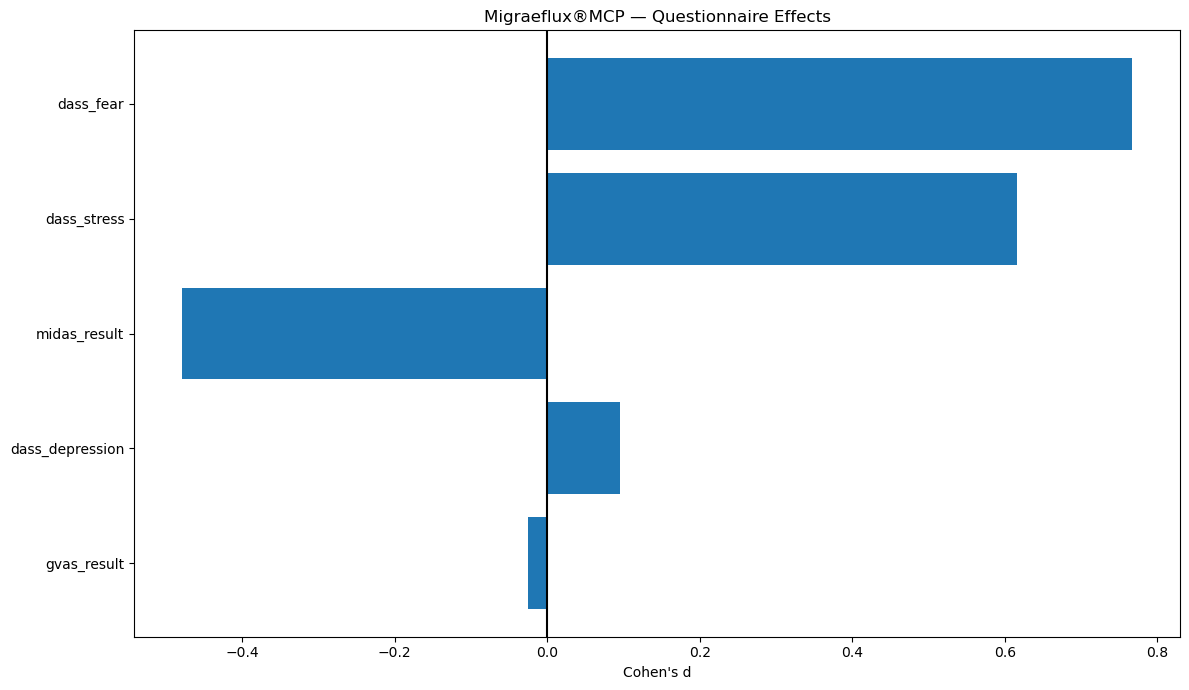

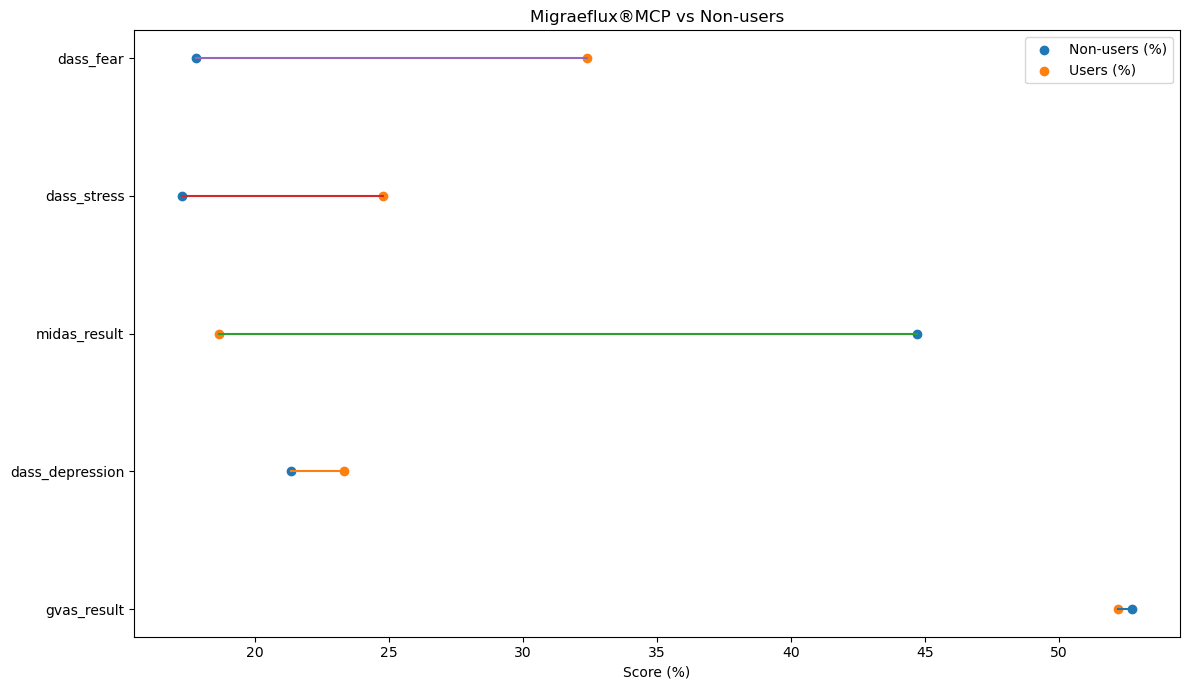

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import re

from scipy.stats import ttest_ind

# =========================================================
# CONFIG
# =========================================================

DATA_DIR = Path("./patienten-visiten")
csv_files = sorted(DATA_DIR.glob("Patients_V*.csv"))

MEDICATION_QUERY = "Lasmiditan"

score_bases = [
    "midas_result",
    "dass_depression",
    "dass_fear",
    "dass_stress",
    "gvas_result",
    "pgic_result"
]

# NEW: score ranges for percentage conversion
score_ranges = {
    "pgic_result": 7,
    "dass_depression": 24,
    "dass_fear": 21,
    "dass_stress": 42,
    "gvas_result": 100,
    "midas_result": 90
}

pattern = rf"\b{re.escape(MEDICATION_QUERY)}"

# =========================================================
# STORAGE (ONLY 1D ARRAYS)
# =========================================================

all_scores = []
all_med_flags = []

# =========================================================
# STREAM FILES (NO WIDE COPIES)
# =========================================================

for file in csv_files:

    df = pd.read_csv(file, sep=";")

    med_cols = [c for c in df.columns if c.startswith("acute_name_a")]
    if not med_cols:
        continue

    med_text = df[med_cols].astype(str).agg(" ".join, axis=1)

    has_med = med_text.str.contains(pattern, case=False, na=False)
    any_med = med_text.str.contains(r"\w", na=False)

    for base in score_bases:

        cols = [c for c in df.columns if c.startswith(base)]
        if not cols:
            continue

        score = df[cols].apply(
            lambda x: pd.to_numeric(x, errors="coerce")
        ).mean(axis=1)

        valid = score.notna()

        if valid.sum() < 10:
            continue

        all_scores.append(score[valid].values)
        all_med_flags.append(has_med[valid].values)

# =========================================================
# MERGE INTO VECTORS (SAFE)
# =========================================================

scores = np.concatenate(all_scores)
med_flag = np.concatenate(all_med_flags)

print("Total samples:", len(scores))

med_scores = scores[med_flag]
ctrl_scores = scores[~med_flag]

# =========================================================
# ANALYSIS PER SCORE TYPE (PERCENTAGES)
# =========================================================

results = []

for base in score_bases:

    med_list = []
    ctrl_list = []

    max_range = score_ranges.get(base, None)
    if max_range is None:
        continue

    for file in csv_files:

        df = pd.read_csv(file, sep=";")

        med_cols = [c for c in df.columns if c.startswith("acute_name_a")]
        if not med_cols:
            continue

        med_text = df[med_cols].astype(str).agg(" ".join, axis=1)
        has_med = med_text.str.contains(pattern, case=False, na=False)

        cols = [c for c in df.columns if c.startswith(base)]
        if not cols:
            continue

        score = df[cols].apply(
            lambda x: pd.to_numeric(x, errors="coerce")
        ).mean(axis=1)

        score = score.dropna()
        has_med = has_med.loc[score.index]

        # NEW: convert to percentage
        score_pct = (score / max_range) * 100

        med_list.append(score_pct[has_med])
        ctrl_list.append(score_pct[~has_med])

    if not med_list or not ctrl_list:
        continue

    med_s = pd.concat(med_list)
    ctrl_s = pd.concat(ctrl_list)

    if len(med_s) < 5 or len(ctrl_s) < 5:
        continue

    # Cohen's d (on percentage scale)
    pooled = np.sqrt(
        ((len(med_s)-1)*med_s.var() + (len(ctrl_s)-1)*ctrl_s.var())
        / (len(med_s)+len(ctrl_s)-2)
    )

    if pooled == 0:
        continue

    d = (med_s.mean() - ctrl_s.mean()) / pooled

    results.append({
        "questionnaire": base,
        "mean_med": med_s.mean(),
        "mean_ctrl": ctrl_s.mean(),
        "cohens_d": d
    })

# =========================================================
# RESULTS
# =========================================================

res = pd.DataFrame(results)

if res.empty:
    print("No results found")
    exit()

res = res.sort_values("cohens_d", key=lambda x: np.abs(x), ascending=True)

# =========================================================
# PLOT 1 (PERCENTAGES)
# =========================================================

plt.figure(figsize=(12, 7))

plt.barh(res["questionnaire"], res["cohens_d"])
plt.axvline(0, color="black")

plt.title("Lasmiditan — Questionnaire Effects")
plt.xlabel("Cohen's d")

plt.tight_layout()
plt.show()

# =========================================================
# PLOT 2 (PERCENTAGES)
# =========================================================

plt.figure(figsize=(12, 7))

y = np.arange(len(res))

plt.scatter(res["mean_ctrl"], y, label="Non-users (%)")
plt.scatter(res["mean_med"], y, label="Users (%)")

for i in range(len(res)):
    plt.plot(
        [res["mean_ctrl"].iloc[i], res["mean_med"].iloc[i]],
        [i, i]
    )

plt.yticks(y, res["questionnaire"])
plt.xlabel("Score (%)")
plt.legend()
plt.title("Lasmiditan vs Non-users")
plt.tight_layout()
plt.show()